# TOF inspection

Loads a combined H5 file, picks one of the zero-padded TOF hit arrays
(`tofs_e`, `tofs_i`, or `liq_tofs_e`), and histograms it onto a
user-supplied TOF grid. Three views:

1. The mean spectrum averaged over every (train, bunch) shot.
2. A 2D map of mean spectrum vs bunch index (averaged over trains).
3. A 2D map of mean spectrum vs train index (averaged over bunches).

To keep memory in check, the full `(n_trains, n_bunches, n_bins)` per-shot
spectra array is never materialised. Instead, the non-zero hits are
flattened once and labelled with their train/bunch index; each plot is
then a single `np.histogram` (1D) or `np.histogram2d` (2D) call.

In [1]:
import sys
from pathlib import Path
_REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(_REPO_ROOT / "analysis" / "scripts"))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import config
from data_loading import load_data

%matplotlib inline

In [2]:
from scipy.signal import savgol_filter

## Parameters

Pick the file + config, the TOF key to inspect, and the bin grid in 100 ps.
`TOF_KEY` must be one of `tofs_e` / `tofs_i` (config 1) or
`liq_tofs_e` (config 2).

In [3]:
H5_FILE    = config.COMBINED_DIR / "glycine_delay_scan_150C_274.0eV.h5"
CONFIG     = 1
TOF_KEY    = "tofs_i"      # tofs_e | tofs_i | liq_tofs_e

TRIM_START   = 3
TRIM_END     = 4
DOWNSAMPLE_N = 1

# TOF histogram grid (100 ps). Edges are np.linspace(TOF_MIN, TOF_MAX, N_BINS + 1).
TOF_MIN = 0.0
TOF_MAX = 40000
N_BINS  = 500

# Log-stretch the 2D maps; helps reveal weak features.
LOG_MAP = False

## Load and pick the TOF array

In [4]:
data = load_data(str(H5_FILE), config=CONFIG,
                 trim_start=TRIM_START, trim_end=TRIM_END,
                 downsample_N=DOWNSAMPLE_N)


In [5]:
tofs = getattr(data, TOF_KEY)
if tofs is None:
    raise ValueError(
        f"{TOF_KEY!r} is not populated for config={CONFIG}. "
        f"Config 1 has tofs_e / tofs_i; config 2 has liq_tofs_e."
    )

n_trains, n_bunches, max_hits = tofs.shape
print(f"file              : {H5_FILE}")
print(f"{TOF_KEY:<18}: shape {tofs.shape}, dtype {tofs.dtype}")
print(f"trains Ãƒâ€” bunches  : {n_trains} Ãƒâ€” {n_bunches} = {n_trains * n_bunches} shots")
print(f"max hits / shot   : {max_hits}")

file              : /home/ogalex/glycine2026/glycine26/11022188/processed/combined/glycine_delay_scan_150C_274.0eV.h5
tofs_i            : shape (32787, 101, 120), dtype uint32
trains Ãƒâ€” bunches  : 32787 Ãƒâ€” 101 = 3311487 shots
max hits / shot   : 120


In [6]:
data.tID

array([2.6603083e+09, 2.6603083e+09, 2.6603083e+09, ..., 2.6603420e+09,
       2.6603420e+09, 2.6603420e+09])

In [7]:
data = data.filter_trains(data.tID, lo=1e8, inside=True)

In [8]:
data.tID.shape

(32787,)

## Index the hits

Flatten the zero-padded TOF array into a 1D list of valid hits, and
label each hit with the train and bunch index it came from. These three
flat `(n_hits,)` arrays are what `np.histogram` / `np.histogram2d` consume
below, so we never materialise the full `(n_trains, n_bunches, n_bins)`
per-shot spectra cube.

In [9]:
tof_edges = np.linspace(TOF_MIN, TOF_MAX, N_BINS + 1)
tof_cents = 0.5 * (tof_edges[:-1] + tof_edges[1:])

valid = tofs != 0
tof_of_hit   = tofs[valid]
train_of_hit = np.broadcast_to(
    np.arange(n_trains)[:, None, None], tofs.shape
)[valid]
bunch_of_hit = np.broadcast_to(
    np.arange(n_bunches)[None, :, None], tofs.shape
)[valid]

n_hits   = tof_of_hit.size
in_win   = (tof_of_hit >= TOF_MIN) & (tof_of_hit < TOF_MAX)
print(f"total non-zero hits: {n_hits}")
print(f"hits in window    : {int(in_win.sum())}")
print(f"tof range         : {TOF_MIN:.1f} .. {TOF_MAX:.1f} 100 ps ({N_BINS} bins)")
print(f"bin width         : {(TOF_MAX - TOF_MIN) / N_BINS:.3f} 100 ps")

total non-zero hits: 2028062
hits in window    : 2026614
tof range         : 0.0 .. 40000.0 100 ps (500 bins)
bin width         : 80.000 100 ps


## Average spectrum (over every shot)

Single `np.histogram` of all valid hits, then divide by the total shot
count to get mean counts per shot.

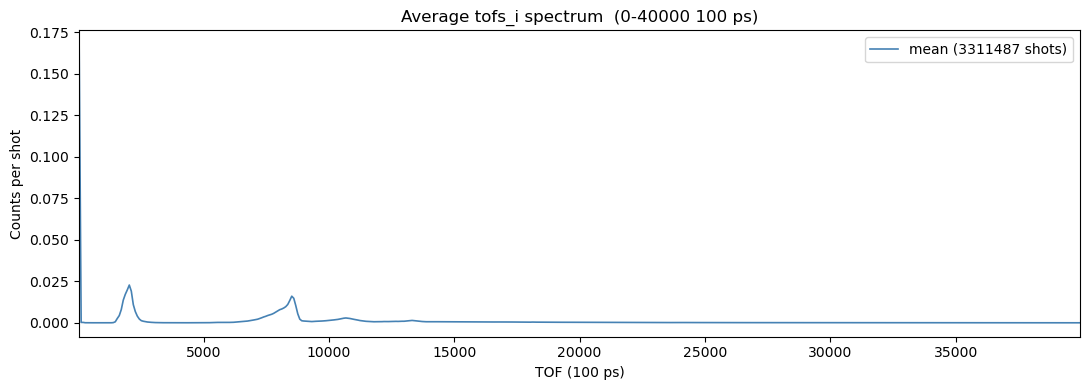

In [10]:
total_counts, _ = np.histogram(tof_of_hit, bins=tof_edges)
mean_spec = total_counts / (n_trains * n_bunches)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tof_cents, mean_spec, color="steelblue", lw=1.2,
        label=f"mean ({n_trains * n_bunches} shots)")
ax.set_xlabel("TOF (100 ps)")
ax.set_ylabel("Counts per shot")
ax.set_title(f"Average {TOF_KEY} spectrum  ({TOF_MIN:.0f}-{TOF_MAX:.0f} 100 ps)")
ax.set_xlim(tof_cents[0], tof_cents[-1])
ax.legend()
fig.tight_layout()
plt.show()

## Mean spectrum vs bunch index

Single `np.histogram2d` with bunch index on one axis and TOF on the
other, divided by `n_trains` to get mean counts per shot at each
(bunch, tof_bin).

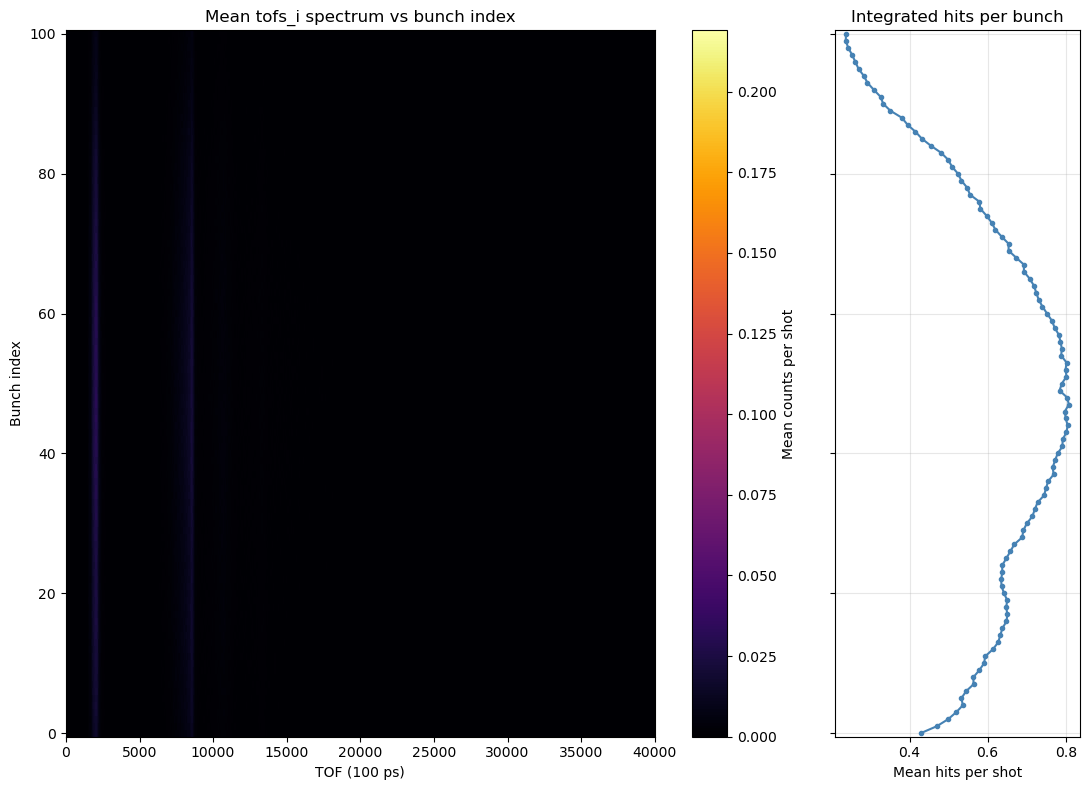

In [11]:
bunch_edges = np.arange(n_bunches + 1)
H_bunch, _, _ = np.histogram2d(
    bunch_of_hit, tof_of_hit,
    bins=[bunch_edges, tof_edges],
)
mean_by_bunch = H_bunch / n_trains   # (n_bunches, n_bins)

fig, axes = plt.subplots(
    1, 2, figsize=(11, 8),
    gridspec_kw={"width_ratios": [3, 1]}, sharey=True,
)

ax = axes[0]
norm = mcolors.LogNorm(vmin=max(np.nanmin(mean_by_bunch), 1e-6),
                       vmax=np.nanmax(mean_by_bunch)) if LOG_MAP else None
im = ax.pcolormesh(tof_cents, np.arange(n_bunches), mean_by_bunch,
                   cmap="inferno", shading="auto", norm=norm)
fig.colorbar(im, ax=ax, label="Mean counts per shot")
ax.set_xlabel("TOF (100 ps)")
ax.set_ylabel("Bunch index")
ax.set_title(f"Mean {TOF_KEY} spectrum vs bunch index")

ax = axes[1]
total_per_bunch = mean_by_bunch.sum(axis=1)
ax.plot(total_per_bunch, np.arange(n_bunches),
        marker="o", ms=3, color="steelblue")
ax.set_xlabel("Mean hits per shot")
ax.set_title("Integrated hits per bunch")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Mean spectrum vs train index

Same approach with train index in place of bunch index, divided by
`n_bunches`.

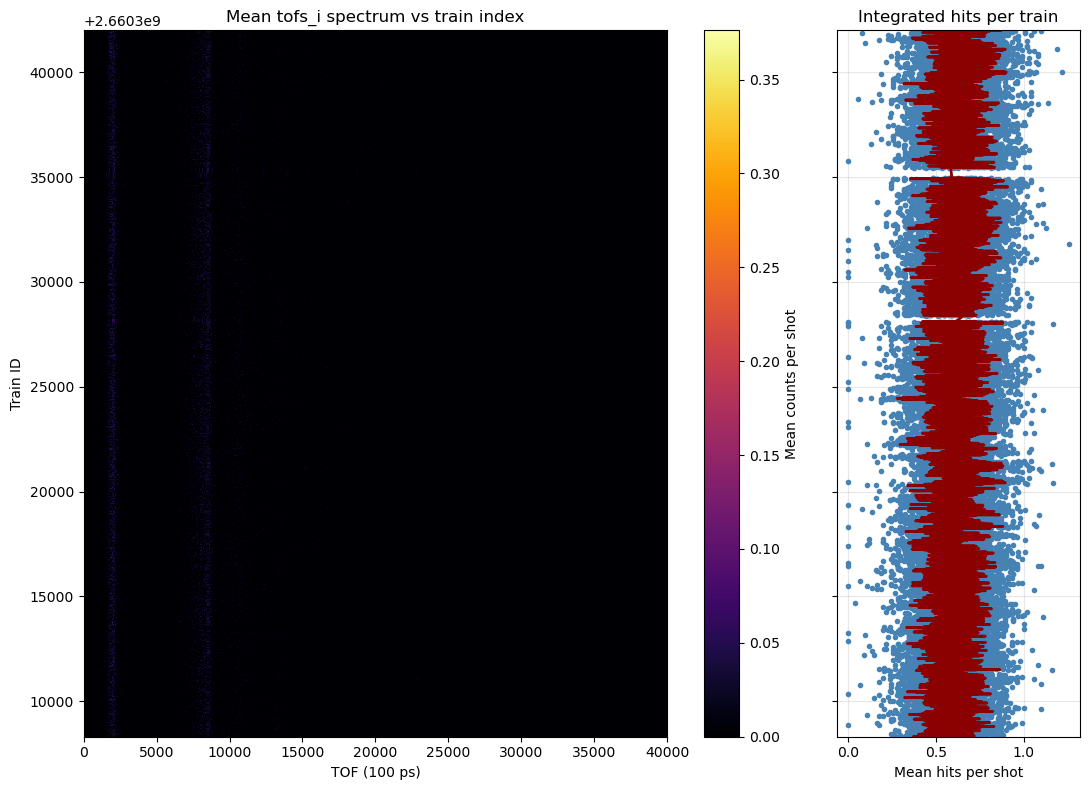

In [12]:
train_edges = np.arange(n_trains + 1)
H_train, _, _ = np.histogram2d(
    train_of_hit, tof_of_hit,
    bins=[train_edges, tof_edges],
)
mean_by_train = H_train / n_bunches   # (n_trains, n_bins)

fig, axes = plt.subplots(
    1, 2, figsize=(11, 8),
    gridspec_kw={"width_ratios": [3, 1]}, sharey=True,
)

ax = axes[0]
norm = mcolors.LogNorm(vmin=max(np.nanmin(mean_by_train), 1e-6),
                       vmax=np.nanmax(mean_by_train)) if LOG_MAP else None
im = ax.pcolormesh(tof_cents, data.tID, mean_by_train,
                   cmap="inferno", shading="auto", norm=norm)
fig.colorbar(im, ax=ax, label="Mean counts per shot")
ax.set_xlabel("TOF (100 ps)")
ax.set_ylabel("Train ID")
ax.set_title(f"Mean {TOF_KEY} spectrum vs train index")

ax = axes[1]
total_per_train = mean_by_train.sum(axis=1)
ax.plot(total_per_train, data.tID,
        marker="o", ms=3, color="steelblue", ls="")
ax.plot(savgol_filter(total_per_train, 9,3), data.tID,
        marker="", ms=3, color="darkred", ls="-", lw='2')

ax.set_xlabel("Mean hits per shot")
ax.set_title("Integrated hits per train")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## GMD vs hit count per shot

Single shots: x = pulse energy from the GMD, y = number of hits in
the TOF window. Each point is one shot; `plt.hist2d` bins them so
dense regions are visible. The Pearson correlation coefficient and
an ordinary least-squares linear fit are overlaid.

Shots filtered out by `filter_shots` have `gmd = NaN` (and zeroed
hits); they're dropped before the fit so the slope and `r` reflect
only the kept shots.

/tmp/ipykernel_4155223/2254742653.py:22: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(x, y, 1)


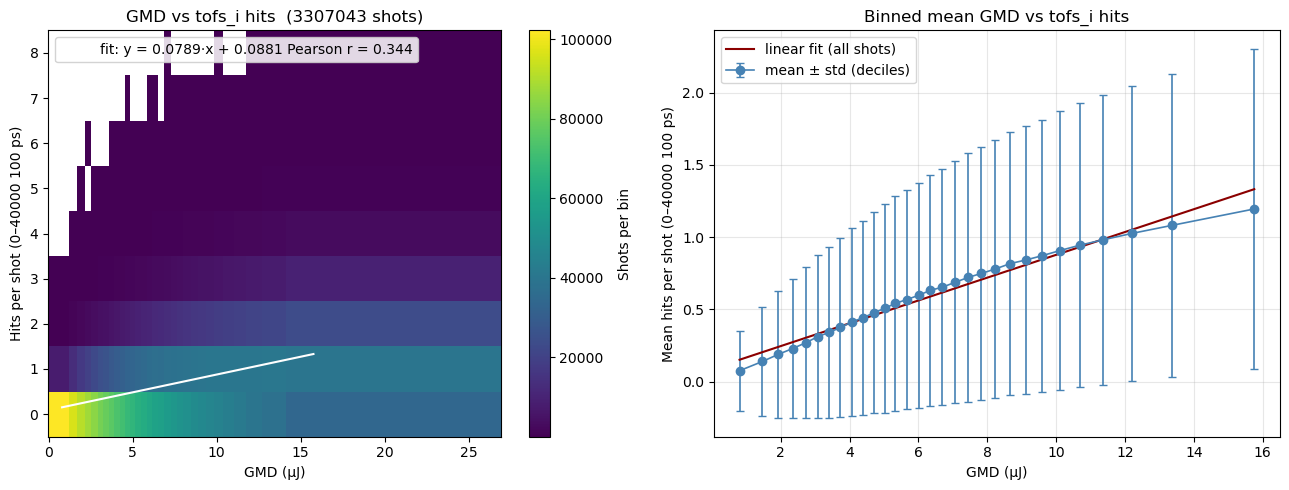

In [13]:
from binning import arb_bool_ar, bin_and_average

# Per-shot hit count inside the TOF window, flat (n_trains * n_bunches,).
shot_id = train_of_hit[in_win] * n_bunches + bunch_of_hit[in_win]
counts_per_shot = np.bincount(shot_id, minlength=n_trains * n_bunches)

gmd_flat = data.gmd.ravel()
good     = np.isfinite(gmd_flat)
x = gmd_flat[good]
y = counts_per_shot[good].astype(float)

# Bin shots by GMD value and average their hit counts in each bin.
N_GMD_BINS = 30
gmd_edges = np.percentile(x, np.linspace(0, 100, N_GMD_BINS + 1))

gmd_cents, bool_ar = arb_bool_ar(gmd_edges, x)
mean_hits, std_hits, n_per_bin = bin_and_average(bool_ar, y)
mean_gmd, _, _ = bin_and_average(bool_ar, x)


r = float(np.corrcoef(x, y)[0, 1])
slope, intercept = np.polyfit(x, y, 1)
slope, intercept = np.polyfit(mean_gmd, mean_hits, 1)
x_line = np.linspace(mean_gmd.min(), mean_gmd.max(), 100)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- left: hist2d of every shot --------------------------------------
h = ax.hist2d(x, y, bins=[gmd_edges, np.arange(10)-.5], cmap="viridis", cmin=1)
fig.colorbar(h[3], ax=ax, label="Shots per bin")
ax.plot(x_line, slope * x_line + intercept, color="white", lw=1.5,
        label=f"fit: y = {slope:.3g}·x + {intercept:.3g} Pearson r = {r:.3f}")
ax.set_xlabel("GMD (µJ)")
ax.set_ylabel(f"Hits per shot ({TOF_MIN:.0f}–{TOF_MAX:.0f} 100 ps)")
ax.set_title(f"GMD vs {TOF_KEY} hits  ({x.size} shots)")
ax.legend(loc="upper left", framealpha=0.85)

# --- right: binned mean ± std ----------------------------------------
ax2.errorbar(mean_gmd, mean_hits, yerr=std_hits,
             fmt="o-", color="steelblue", capsize=3, lw=1.2,
#              label=f"mean ± std ({N_GMD_BINS} GMD bins)")
             label=f"mean ± std (deciles)")
ax2.plot(x_line, slope * x_line + intercept, color="darkred", lw=1.5,
         label="linear fit (all shots)")
ax2.set_xlabel("GMD (µJ)")
ax2.set_ylabel(f"Mean hits per shot ({TOF_MIN:.0f}–{TOF_MAX:.0f} 100 ps)")
ax2.set_title(f"Binned mean GMD vs {TOF_KEY} hits")
ax2.legend(loc="upper left")
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Average TOF spectrum per GMD bin

Same percentile GMD bins as above. For each in-window hit, look up
the GMD bin of its parent shot and histogram by (gmd_bin, tof) in a
single `np.histogram2d` call — so the per-shot spectra cube is
never materialised. Each row of the resulting `(n_gmd_bins, n_tof_bins)`
array is divided by `n_per_bin` to get mean counts per shot.

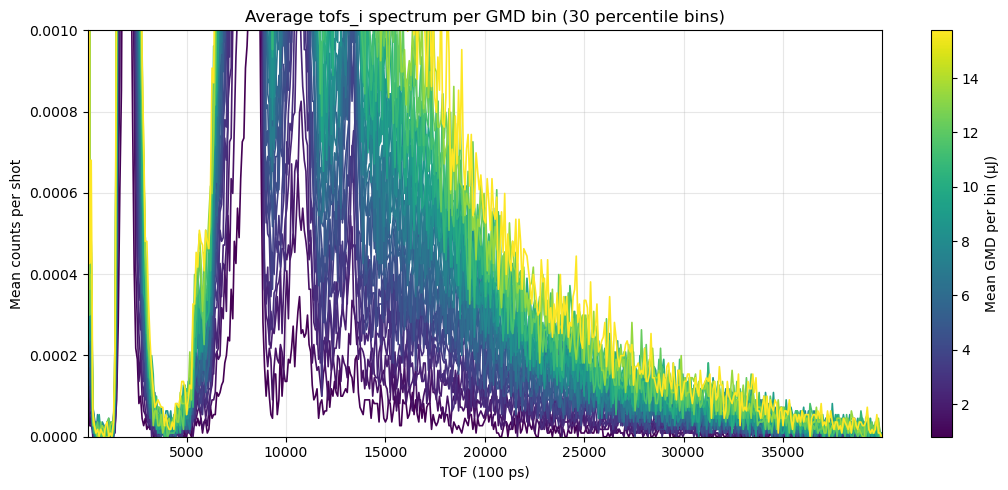

In [17]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

n_gmd_bins = bool_ar.shape[0]

# Map each flat shot index to its GMD bin (-1 if not in any bin).
gmd_bin_of_shot = np.full(n_trains * n_bunches, -1, dtype=int)
good_idx = np.flatnonzero(good)
for i in range(n_gmd_bins):
    gmd_bin_of_shot[good_idx[bool_ar[i]]] = i

# In-window hits and their parent shot's GMD bin.
tof_in = tof_of_hit[in_win]
shot_id = train_of_hit[in_win] * n_bunches + bunch_of_hit[in_win]
hit_gmd_bin = gmd_bin_of_shot[shot_id]
keep = hit_gmd_bin >= 0

H_gmd, _, _ = np.histogram2d(
    hit_gmd_bin[keep], tof_in[keep],
    bins=[np.arange(n_gmd_bins + 1) - 0.5, tof_edges],
)
mean_spec_by_gmd = H_gmd / n_per_bin[:, None]   # (n_gmd_bins, n_tof_bins)

norm = Normalize(vmin=float(mean_gmd[0]), vmax=float(mean_gmd[-1]))
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(11, 5))
for cent, spec in zip(mean_gmd, mean_spec_by_gmd):
    ax.plot(tof_cents, spec, color=cmap(norm(cent)), lw=1.2)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Mean GMD per bin (µJ)")
ax.set_xlabel("TOF (100 ps)")
ax.set_ylabel("Mean counts per shot")
ax.set_title(f"Average {TOF_KEY} spectrum per GMD bin ({n_gmd_bins} percentile bins)")
ax.set_xlim(tof_cents[0], tof_cents[-1])
ax.set_ylim(0, .001)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

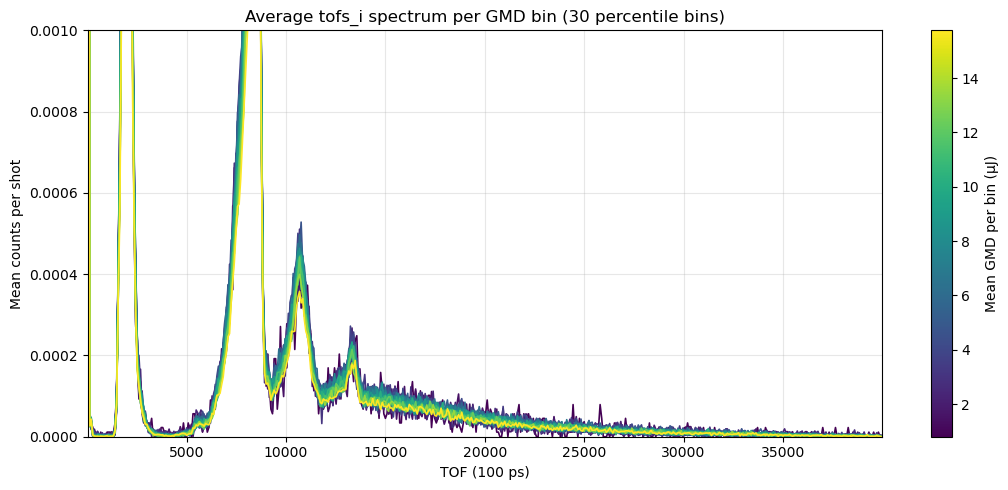

In [19]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

n_gmd_bins = bool_ar.shape[0]

# Map each flat shot index to its GMD bin (-1 if not in any bin).
gmd_bin_of_shot = np.full(n_trains * n_bunches, -1, dtype=int)
good_idx = np.flatnonzero(good)
for i in range(n_gmd_bins):
    gmd_bin_of_shot[good_idx[bool_ar[i]]] = i

# In-window hits and their parent shot's GMD bin.
tof_in = tof_of_hit[in_win]
shot_id = train_of_hit[in_win] * n_bunches + bunch_of_hit[in_win]
hit_gmd_bin = gmd_bin_of_shot[shot_id]
keep = hit_gmd_bin >= 0

H_gmd, _, _ = np.histogram2d(
    hit_gmd_bin[keep], tof_in[keep],
    bins=[np.arange(n_gmd_bins + 1) - 0.5, tof_edges],
)
mean_spec_by_gmd = (H_gmd / n_per_bin[:, None])/mean_gmd[:, np.newaxis]   # (n_gmd_bins, n_tof_bins)

norm = Normalize(vmin=float(mean_gmd[0]), vmax=float(mean_gmd[-1]))
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(11, 5))
for cent, spec in zip(mean_gmd, mean_spec_by_gmd):
    ax.plot(tof_cents, spec, color=cmap(norm(cent)), lw=1.2)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Mean GMD per bin (µJ)")
ax.set_xlabel("TOF (100 ps)")
ax.set_ylabel("Mean counts per shot")
ax.set_title(f"Average {TOF_KEY} spectrum per GMD bin ({n_gmd_bins} percentile bins)")
ax.set_xlim(tof_cents[0], tof_cents[-1])
ax.set_ylim(0, .001)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()